# Potomac Sewage Spill (Jan 2026) — Event Overlay Demo

A first-look visualization of the [`OlmoEarth-v1-Potomac-Sewage-Spill-2026`](https://huggingface.co/datasets/BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026) reference dataset for the January 19, 2026 Potomac Interceptor sewage spill: 846 daily discharge observations across the Potomac corridor, anchored to a 4-phase event timeline plus a 71-event operational log.

## What You'll Learn

- How to pull the daily flow data and the operational event log from Hugging Face
- The 4-phase event timeline and what each phase represents
- The corridor's gauge layout (upstream control → near-spill → tidal DC → lower Potomac)
- Per-gauge daily discharge with the event phases overlaid
- The discharge anomaly at the near-spill gauge during active release vs the upstream control
- How the operational event log is distributed across phases and event types

## Why

When triaging a discharge event, Civil & Environmental Engineering practitioners need to see at a glance: *where* the spill happened, *when* each phase began and ended, *which* gauges saw measurable change, and *how big* the anomaly was relative to upstream baseline. This demo answers all four in under a minute.

## Requirements

- Python 3.11
- `pandas`, `matplotlib`, `datasets`, `huggingface_hub` (see `requirements.txt`)
- ~1 minute runtime, no GPU required

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from datasets import load_dataset
from huggingface_hub import hf_hub_download

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

# --- Constants reused throughout the notebook ---
PHASE_ORDER = ['pre_spill_baseline', 'active_release', 'bypass_period', 'post_recovery']

PHASE_LABELS = {
    'pre_spill_baseline': 'Pre-spill baseline',
    'active_release':     'Active release',
    'bypass_period':      'Bypass period',
    'post_recovery':      'Post-recovery',
}

PHASE_DESCRIPTIONS = {
    'pre_spill_baseline': 'Reference window before the spill',
    'active_release':     'Initial collapse, max untreated discharge',
    'bypass_period':      'Bypass active, ongoing reduced impact',
    'post_recovery':      'Repairs complete, recovery monitoring',
}

PHASE_COLORS = {
    'pre_spill_baseline': '#cfd8dc',
    'active_release':     '#ef5350',
    'bypass_period':      '#ffb74d',
    'post_recovery':      '#aed581',
}

# Gauge roles ordered upstream -> downstream along the corridor
ROLE_ORDER = [
    'upstream_control',
    'upstream_chain_bridge',
    'near_spill',
    'tidal_dc',
    'mid_potomac',
    'lower_potomac',
    'anacostia_tributary',
    'anacostia_lower',
]

# Approximate spill site (from dataset metadata: Glen Echo / Little Falls vicinity)
SPILL_SITE = (38.9676, -77.1437)

## 1. Load the daily flow data

Pull the main parquet from Hugging Face — daily discharge spanning Dec 1 2025 → Mar 31 2026.

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026")
df = ds["train"].to_pandas()
df['date'] = pd.to_datetime(df['date'])
print(f"Rows: {len(df):,}  |  Stations: {df['site_no'].nunique()}  |  Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
df.head()

Rows: 846  |  Stations: 7  |  Date range: 2025-12-01 -> 2026-03-31


,site_no,date,discharge_cfs,role,phase,name,latitude,longitude
0,01638500,2025-12-01,1830.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111
1,01638500,2025-12-02,1870.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111
2,01638500,2025-12-03,1990.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111
3,01638500,2025-12-04,1960.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111
4,01638500,2025-12-05,1910.0,upstream_control,pre_spill_baseline,"Potomac River at Point of Rocks, MD",39.273583,-77.543111


## 2. The 4-phase event timeline

The dataset divides the observation window into four phases marking the lifecycle of the spill event.

In [3]:
phase_summary = (
    df.groupby('phase', observed=True)['date']
      .agg(start='min', end='max', station_days='count')
      .reindex(PHASE_ORDER)
)
phase_summary['days'] = (phase_summary['end'] - phase_summary['start']).dt.days + 1
phase_summary['description'] = [PHASE_DESCRIPTIONS[p] for p in phase_summary.index]
phase_summary[['start', 'end', 'days', 'station_days', 'description']]

,start,end,days,station_days,description
phase,,,,,
pre_spill_baseline,2025-12-01,2026-01-18,49,343,Reference window before the spill
active_release,2026-01-19,2026-01-24,6,42,"Initial collapse, max untreated discharge"
bypass_period,2026-01-25,2026-03-14,49,342,"Bypass active, ongoing reduced impact"
post_recovery,2026-03-15,2026-03-31,17,119,"Repairs complete, recovery monitoring"


## 3. The corridor: gauge layout

The USGS gauges run from upstream of the spill site (Point of Rocks, MD) down through the tidal DC reach toward the lower Potomac. The role labels make the spatial logic explicit: which gauges are baseline, which are at-spill, and which are downstream.

 site_no                  role                                                         name
01638500      upstream_control                          Potomac River at Point of Rocks, MD
01646000 upstream_chain_bridge             Potomac River near Washington, DC (Chain Bridge)
01646500            near_spill Potomac River near Washington, DC, Little Falls Pump Station
01652500              tidal_dc              Potomac River at Wisconsin Ave., Washington, DC
01658500           mid_potomac                  South Fork Quantico Creek near Triangle, VA
01661050         lower_potomac                         St. Clements Creek near Clements, MD
01649500   anacostia_tributary            Northeast Branch Anacostia River at Riverdale, MD


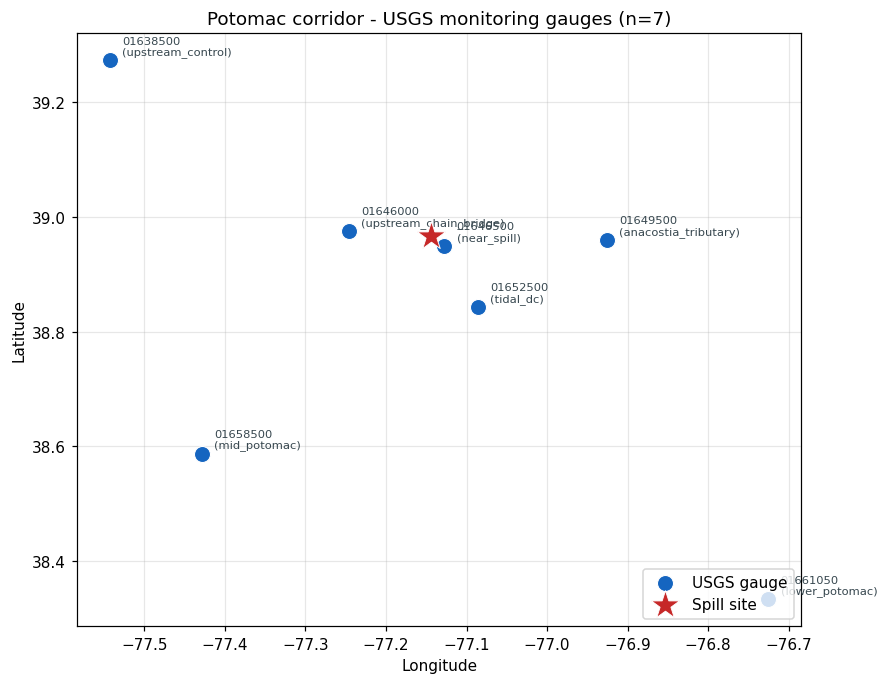

In [4]:
stn_meta = (
    df.drop_duplicates('site_no')[['site_no', 'name', 'role', 'latitude', 'longitude']]
      .reset_index(drop=True)
)
stn_meta['order'] = stn_meta['role'].map({r: i for i, r in enumerate(ROLE_ORDER)})
stn_meta = stn_meta.sort_values('order').reset_index(drop=True)
print(stn_meta[['site_no', 'role', 'name']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(stn_meta['longitude'], stn_meta['latitude'], s=110,
           color='#1565c0', edgecolor='white', linewidth=0.7, zorder=3, label='USGS gauge')
for _, r in stn_meta.iterrows():
    ax.annotate(f"{r['site_no']}\n({r['role']})",
                (r['longitude'], r['latitude']),
                xytext=(8, 4), textcoords='offset points', fontsize=7.5,
                color='#37474f', linespacing=1.05)

ax.scatter([SPILL_SITE[1]], [SPILL_SITE[0]], marker='*', s=380,
           color='#c62828', edgecolor='white', linewidth=0.6, zorder=4, label='Spill site')
ax.legend(loc='lower right', frameon=True)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Potomac corridor - USGS monitoring gauges (n={len(stn_meta)})")
ax.grid(alpha=0.3)
plt.show()

## 4. Daily discharge with event phases overlaid

One panel per gauge, ordered upstream → downstream. Background shading marks the four event phases — making it visible at a glance which gauges saw flow signatures during the active release vs the bypass period.

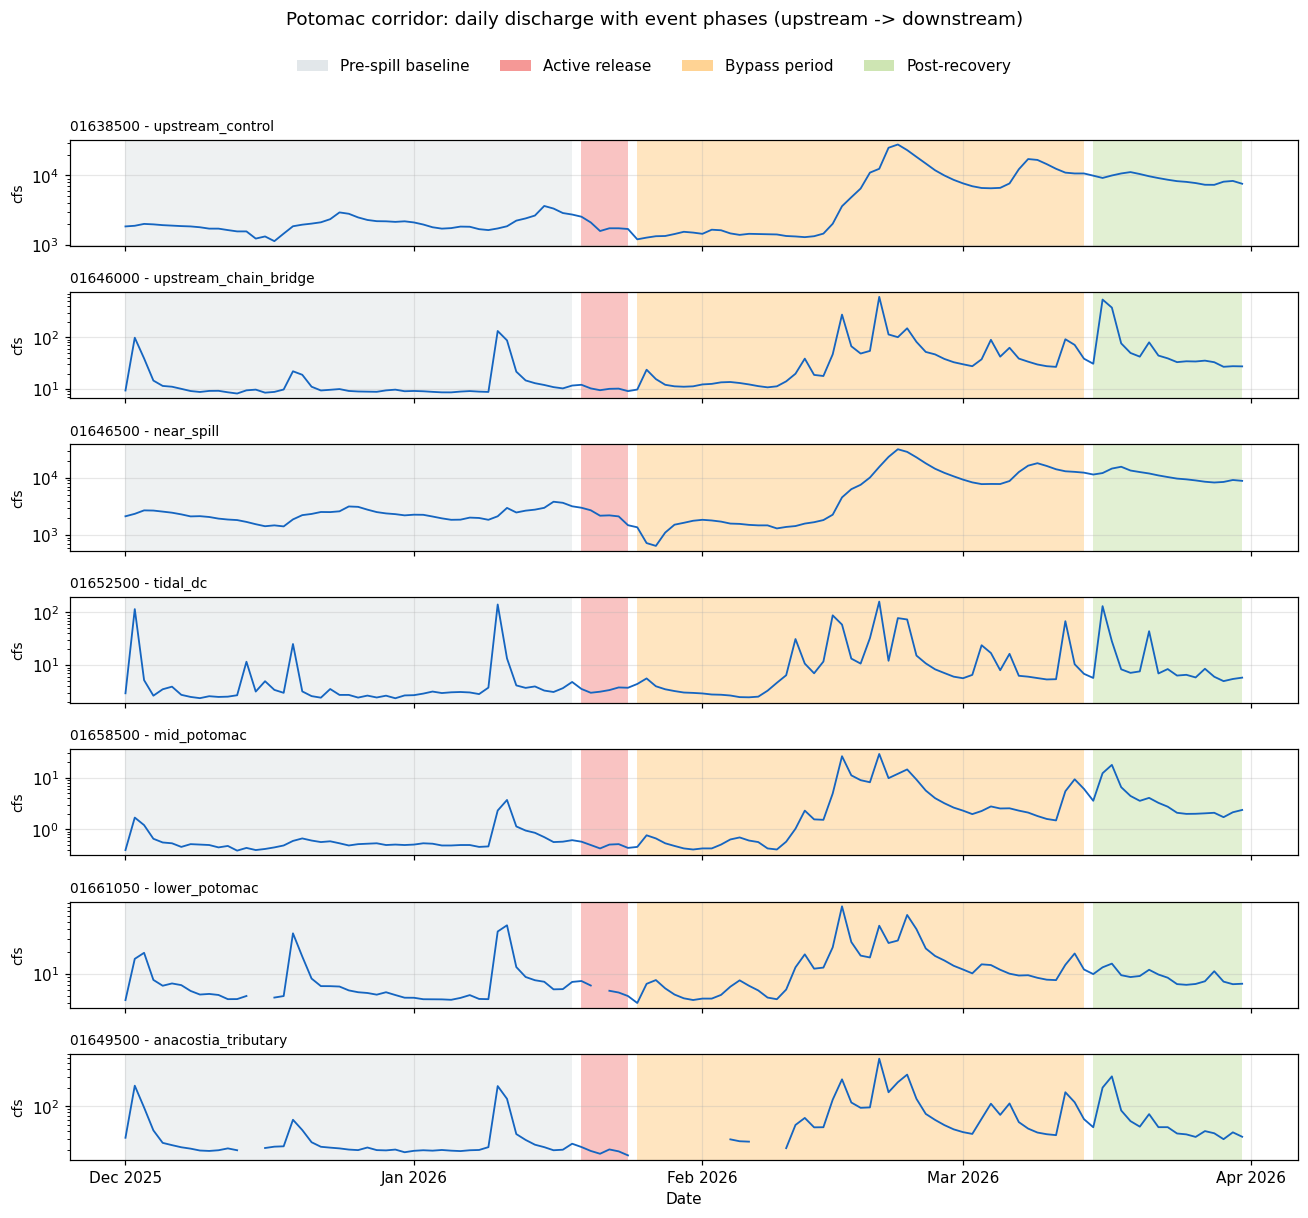

In [5]:
phase_bounds = {p: (phase_summary.loc[p, 'start'], phase_summary.loc[p, 'end'])
                for p in PHASE_ORDER if p in phase_summary.index and pd.notna(phase_summary.loc[p, 'start'])}

gauges_in_data = (
    df.groupby('site_no')
      .agg(role=('role', 'first'), name=('name', 'first'), n=('discharge_cfs', 'count'))
      .reset_index()
      .merge(pd.DataFrame({'role': ROLE_ORDER, 'order': range(len(ROLE_ORDER))}), on='role')
      .sort_values('order')
)

n_panels = len(gauges_in_data)
fig, axes = plt.subplots(n_panels, 1, figsize=(12, 1.5 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, gauges_in_data.iterrows()):
    sno = row['site_no']
    s = df[df['site_no'] == sno].sort_values('date')
    for ph, (a, b) in phase_bounds.items():
        ax.axvspan(a, b, color=PHASE_COLORS[ph], alpha=0.35, lw=0)
    ax.plot(s['date'], s['discharge_cfs'], lw=1.2, color='#1565c0')
    ax.set_yscale('log')
    ax.set_ylabel("cfs", fontsize=9)
    ax.set_title(f"{sno} - {row['role']}", fontsize=9, loc='left')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend_handles = [Patch(facecolor=PHASE_COLORS[p], alpha=0.6, label=PHASE_LABELS[p])
                  for p in PHASE_ORDER if p in phase_bounds]
fig.legend(handles=legend_handles, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Potomac corridor: daily discharge with event phases (upstream -> downstream)", y=1.05)
plt.tight_layout()
plt.show()

## 5. Phase-by-phase mean discharge

Mean discharge by gauge × phase. Comparing each gauge's `active_release` value against its own `pre_spill_baseline` is a quick way to surface gauges that responded to the event.

In [6]:
phase_stats = (
    df.groupby(['site_no', 'role', 'phase'], observed=True)['discharge_cfs']
      .mean()
      .unstack('phase')
      .reindex(columns=PHASE_ORDER)
)
phase_stats = (
    phase_stats.reset_index()
      .merge(pd.DataFrame({'role': ROLE_ORDER, 'order': range(len(ROLE_ORDER))}), on='role')
      .sort_values('order')
      .drop(columns='order')
      .set_index(['site_no', 'role'])
      .round(0)
)
phase_stats

,,pre_spill_baseline,active_release,bypass_period,post_recovery
site_no,role,,,,
01638500,upstream_control,2019.0,1885.0,7315.0,8941.0
01646000,upstream_chain_bridge,17.0,10.0,55.0,90.0
01646500,near_spill,2320.0,2275.0,8225.0,10830.0
01652500,tidal_dc,9.0,3.0,18.0,18.0
01658500,mid_potomac,1.0,0.0,4.0,4.0
01661050,lower_potomac,9.0,6.0,15.0,9.0
01649500,anacostia_tributary,36.0,19.0,103.0,70.0


## 6. Upstream control vs near-spill: anomaly during active release

Compare daily discharge at `upstream_control` (Point of Rocks, MD — well above the spill) and `near_spill` during the `active_release` window. The lower panel plots the daily ratio `near_spill / upstream_control`; the dashed line is the pre-spill baseline ratio. Deviation during the red shading is evidence of an event-driven flow signature local to the spill site.

Upstream control:  01638500
Near-spill:        01646500
Pre-spill baseline ratio (near_spill / upstream_control): 1.159
Active-release   ratio (near_spill / upstream_control): 1.207
Anomaly factor (active / baseline): 1.041


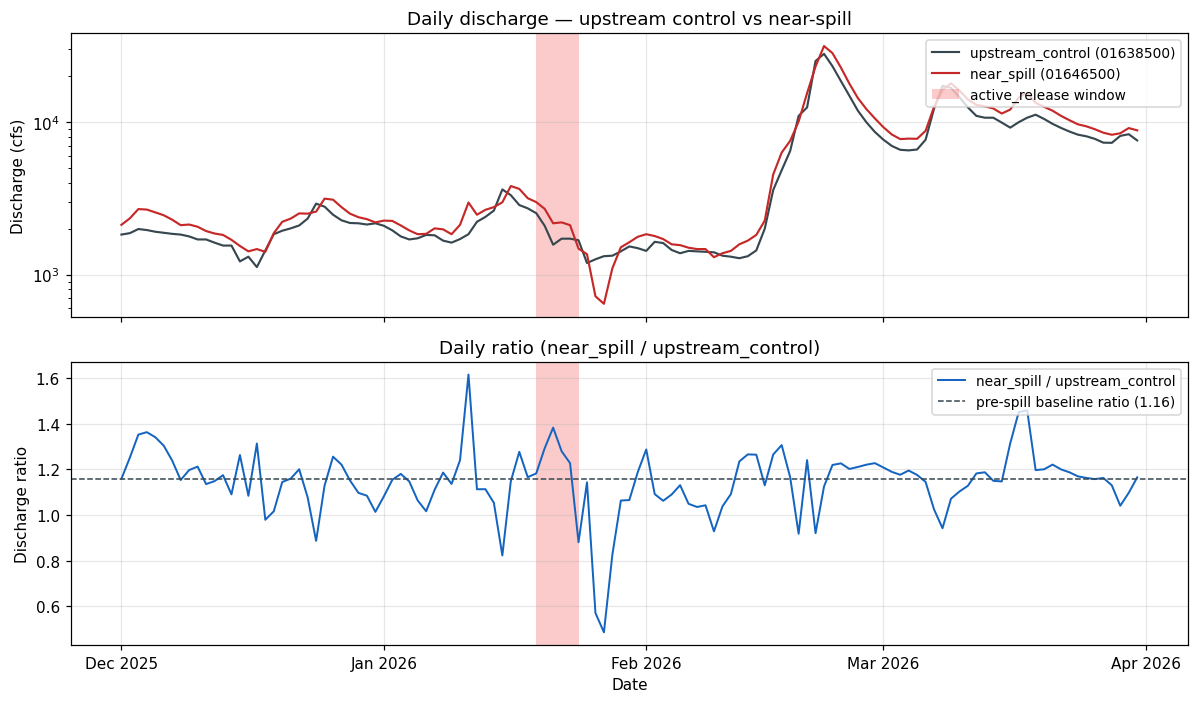

In [7]:
def gauge_series_by_role(role):
    sub = df[df['role'] == role]
    if sub.empty:
        return None, None
    sno = sub['site_no'].iloc[0]
    s = sub.sort_values('date').set_index('date')['discharge_cfs']
    return sno, s

us_sno, us = gauge_series_by_role('upstream_control')
ns_sno, ns = gauge_series_by_role('near_spill')

active_start = phase_summary.loc['active_release', 'start']
active_end   = phase_summary.loc['active_release', 'end']
baseline_start = phase_summary.loc['pre_spill_baseline', 'start']
baseline_end   = phase_summary.loc['pre_spill_baseline', 'end']

aligned = pd.concat([us.rename('upstream'), ns.rename('near_spill')], axis=1).dropna()
ratio = aligned['near_spill'] / aligned['upstream']
baseline_ratio = ratio.loc[baseline_start:baseline_end].mean()
active_ratio   = ratio.loc[active_start:active_end].mean()

print(f"Upstream control:  {us_sno}")
print(f"Near-spill:        {ns_sno}")
print(f"Pre-spill baseline ratio (near_spill / upstream_control): {baseline_ratio:.3f}")
print(f"Active-release   ratio (near_spill / upstream_control): {active_ratio:.3f}")
print(f"Anomaly factor (active / baseline): {active_ratio / baseline_ratio:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

ax = axes[0]
ax.plot(us.index, us.values, lw=1.4, color='#37474f', label=f'upstream_control ({us_sno})')
ax.plot(ns.index, ns.values, lw=1.4, color='#c62828', label=f'near_spill ({ns_sno})')
ax.axvspan(active_start, active_end, color=PHASE_COLORS['active_release'], alpha=0.30, lw=0,
           label='active_release window')
ax.set_yscale('log')
ax.set_ylabel("Discharge (cfs)")
ax.set_title("Daily discharge — upstream control vs near-spill")
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ratio.index, ratio.values, lw=1.3, color='#1565c0',
        label='near_spill / upstream_control')
ax.axhline(baseline_ratio, color='#37474f', lw=1.0, ls='--',
           label=f'pre-spill baseline ratio ({baseline_ratio:.2f})')
ax.axvspan(active_start, active_end, color=PHASE_COLORS['active_release'], alpha=0.30, lw=0)
ax.set_ylabel("Discharge ratio")
ax.set_xlabel("Date")
ax.set_title("Daily ratio (near_spill / upstream_control)")
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()

## 7. Operational event log: density across phases

The companion `event_log.csv` records 71 operational events from DC Water and partner agencies. Stacked-bar count by phase × event type shows where reporting effort concentrated.

Total events: 71  |  Date range: 2026-01-19 -> 2026-04-28


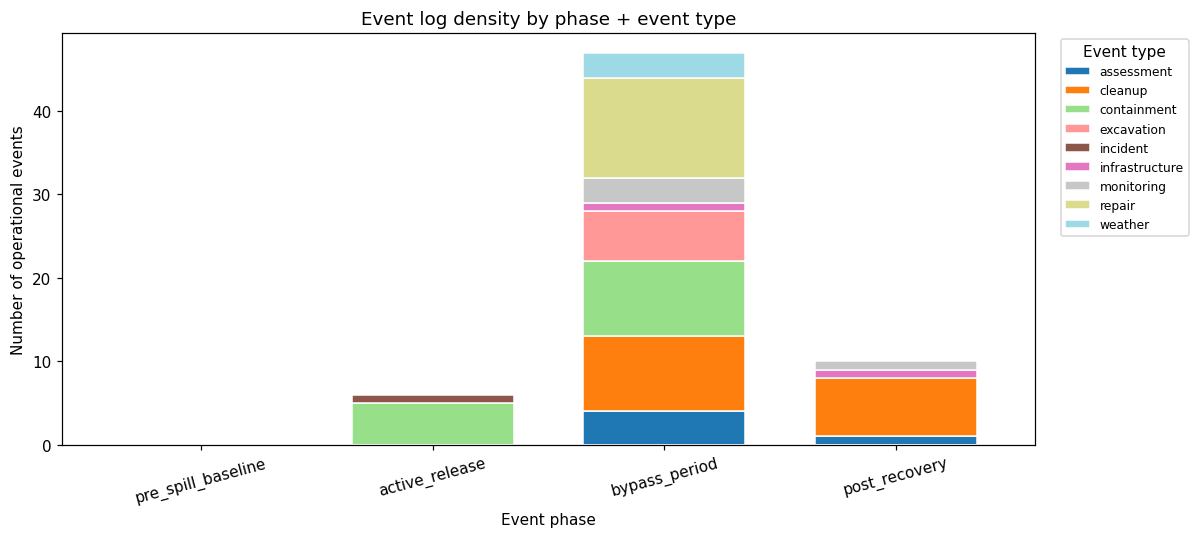

event_type,assessment,cleanup,containment,excavation,incident,infrastructure,monitoring,repair,weather
phase,,,,,,,,,
pre_spill_baseline,0,0,0,0,0,0,0,0,0
active_release,0,0,5,0,1,0,0,0,0
bypass_period,4,9,9,6,0,1,3,12,3
post_recovery,1,7,0,0,0,1,1,0,0


In [8]:
event_log_path = hf_hub_download(
    repo_id="BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026",
    filename="event_log.csv",
    repo_type="dataset",
)
events = pd.read_csv(event_log_path, parse_dates=['date'])
print(f"Total events: {len(events)}  |  Date range: {events['date'].min().date()} -> {events['date'].max().date()}")

ct = (
    events.groupby(['phase', 'event_type'])
          .size().unstack(fill_value=0)
          .reindex(PHASE_ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 5))
ct.plot(kind='bar', stacked=True, ax=ax, edgecolor='white', width=0.7, colormap='tab20')
ax.set_xlabel("Event phase")
ax.set_ylabel("Number of operational events")
ax.set_title("Event log density by phase + event type")
ax.legend(title='Event type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
ct

## What you've seen, and what's next

**Takeaways from this 1-minute look:**

- The 4-phase timeline cleanly partitions the Dec 2025 → Mar 2026 window: a baseline window, a brief active release, a multi-week bypass period, and a recovery window.
- Raw discharge at the near-spill gauge is dominated by ambient seasonal Potomac flow (thousands of cfs); the bypass discharge is small relative to baseflow, so the event signature is *not* obvious in raw cfs traces.
- Normalizing by the upstream control (Point of Rocks) and tracking the daily ratio is a far more sensitive way to surface event-driven anomalies — it controls for shared upstream weather and lets you see local-to-spill effects.
- The operational event log concentrates in the bypass period (cleanup + repair + monitoring activity), with the active-release window dominated by initial-response activity.

**Next notebooks in this repo:**

- **`02_data_prep.ipynb`** — rebuild the dataset from raw USGS NWIS pulls and agency reporting, including phase-label assignment and event-log curation.
- **`03_tutorial_embeddings.ipynb`** — interpret discharge and event signals in light of the AOI corridor polygons; introduce remote-sensing context.
- **`04_analysis.ipynb`** — cross-reference the operational log with the discharge anomaly windows to build an integrated event chronology.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*